In [40]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import itertools
import time

In [41]:
def generate_graph(num_nodes=5, seed=42):
    np.random.seed((int(time.time())))  # For reproducibility
    G = nx.complete_graph(num_nodes)  # Create a fully connected graph

    # Assign random weights (distances) to edges
    for (u, v) in G.edges():
        G[u][v]['weight'] = np.random.randint(10, 100)  # Random distances between 10 and 100

    return G

# Create the graph
G = generate_graph(num_nodes=5)


In [42]:
def tsp_brute_force(G):
    nodes = list(G.nodes)
    min_cost = float('inf')
    best_path = None

    # Generate all possible permutations of cities
    for perm in itertools.permutations(nodes[1:]):  # Fix first city to reduce redundant cycles
        path = [nodes[0]] + list(perm) + [nodes[0]]  # Create a round trip
        cost = sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))

        if cost < min_cost:
            min_cost = cost
            best_path = path

    return best_path, min_cost

# Run Brute Force TSP
best_path_bf, min_cost_bf = tsp_brute_force(G)
print(f"Brute Force Solution: {best_path_bf}, Cost: {min_cost_bf}")


Brute Force Solution: [0, 1, 2, 4, 3, 0], Cost: 198


In [43]:
def tsp_nearest_neighbor(G, start=0):
    unvisited = set(G.nodes)
    path = [start]
    unvisited.remove(start)
    total_cost = 0

    while unvisited:
        last = path[-1]
        nearest = min(unvisited, key=lambda node: G[last][node]['weight'])
        total_cost += G[last][nearest]['weight']
        path.append(nearest)
        unvisited.remove(nearest)

    # Return to start point
    total_cost += G[path[-1]][start]['weight']
    path.append(start)

    return path, total_cost

# Run Nearest Neighbor Heuristic
best_path_nn, min_cost_nn = tsp_nearest_neighbor(G)
print(f"Nearest Neighbor Solution: {best_path_nn}, Cost: {min_cost_nn}")


Nearest Neighbor Solution: [0, 3, 4, 2, 1, 0], Cost: 198


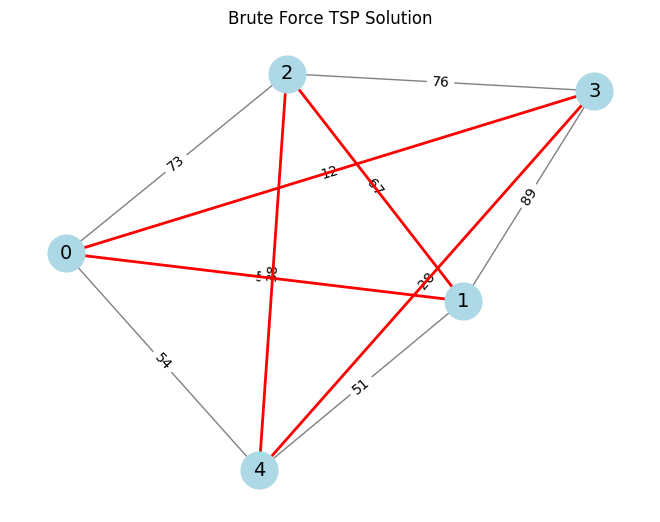

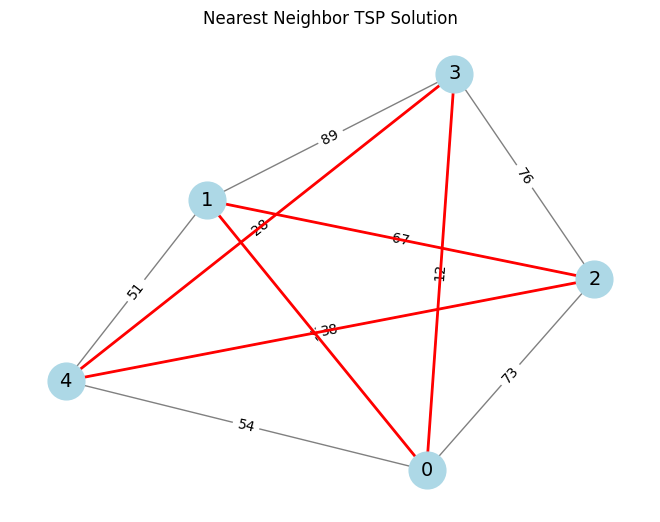

In [44]:
def draw_tsp_solution(G, path, title="TSP Solution"):
    pos = nx.spring_layout(G)  # Position nodes using force-directed layout

    # Draw graph with edge labels
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700, font_size=14)
    edge_labels = {(u, v): G[u][v]['weight'] for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

    # Highlight TSP path
    path_edges = list(zip(path, path[1:]))  # Convert path into edge pairs
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)

    plt.title(title)
    plt.show()

# Plot the results
draw_tsp_solution(G, best_path_bf, title="Brute Force TSP Solution")
draw_tsp_solution(G, best_path_nn, title="Nearest Neighbor TSP Solution")


In [45]:
print(f"Brute Force -> Path: {best_path_bf}, Cost: {min_cost_bf}")
print(f"Nearest Neighbor -> Path: {best_path_nn}, Cost: {min_cost_nn}")

if min_cost_bf < min_cost_nn:
    print("Brute Force found a better solution (Guaranteed Optimal).")
else:
    print("Nearest Neighbor found a suboptimal solution but is much faster.")


Brute Force -> Path: [0, 1, 2, 4, 3, 0], Cost: 198
Nearest Neighbor -> Path: [0, 3, 4, 2, 1, 0], Cost: 198
Nearest Neighbor found a suboptimal solution but is much faster.
